# Team Age Distribution Analysis

Analyze the age distribution of players across all 10 teams in the Montenegrin First League.

**Note:** Player ages are calculated at the time of each match, not current age. This provides a more accurate historical analysis weighted by minutes played in each game.

In [39]:
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [40]:
# Path configuration
LEAGUE = 'cg'  # 'cg' = Montenegro 1. CFL | 'srb' = Serbian SuperLiga

DATA_DIR = Path("..") / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed" / LEAGUE
OUTPUT_DIR = Path("..") / "outputs" / LEAGUE / "figures"

OUT_DIR = RAW_DATA_DIR / LEAGUE
RAW_DIR = OUT_DIR / "raw_by_match"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [41]:
# Load matches to get team mapping, timestamps, and filter postponed matches
matches_df = pd.read_csv(OUT_DIR / "matches.csv")
matches_df_clean = matches_df[matches_df['status.description'] != 'Postponed'].copy()
valid_match_ids = set(matches_df_clean['id'].astype(str))

# Create team mapping
team_mapping = {}
for _, row in matches_df_clean.iterrows():
    team_mapping[row['homeTeam.id']] = row['homeTeam.name']
    team_mapping[row['awayTeam.id']] = row['awayTeam.name']

# Create match timestamp mapping
match_timestamps = dict(zip(matches_df_clean['id'].astype(str), matches_df_clean['startTimestamp']))

print(f"✅ Found {len(team_mapping)} teams in the league")
print(f"✅ Loaded timestamps for {len(match_timestamps)} matches")
print(f"\nTeams: {', '.join(sorted(team_mapping.values()))}")

✅ Found 10 teams in the league
✅ Loaded timestamps for 125 matches

Teams: FK Arsenal Tivat, FK Bokelj Kotor, FK Budućnost Podgorica, FK Dečić Tuzi, FK Jedinstvo Bijelo Polje, FK Jezero, FK Mornar Bar, FK Sutjeska Nikšić, Mladost DG, OFK Petrovac


In [42]:
# Extract player information including birth dates from lineups
player_info_list = []

for match_dir in RAW_DIR.glob("*"):
    # Skip postponed matches
    if match_dir.name not in valid_match_ids:
        continue
    
    lineups_file = match_dir / "lineups.json"
    if lineups_file.exists():
        try:
            with open(lineups_file, encoding='utf-8') as f:
                lineups_data = json.load(f)
            
            # Get match info for team IDs and names from match metadata
            match_info = matches_df_clean[matches_df_clean['id'] == int(match_dir.name)].iloc[0]
            team_ids = {
                'home': int(match_info['homeTeam.id']),
                'away': int(match_info['awayTeam.id'])
            }
            team_names = {
                'home': match_info['homeTeam.name'],
                'away': match_info['awayTeam.name']
            }
            
            # Extract from both teams
            for team_side in ['home', 'away']:
                if team_side in lineups_data:
                    team_data = lineups_data[team_side]
                    players = team_data.get('players', [])
                    
                    for player_entry in players:
                        player = player_entry.get('player', {})
                        stats = player_entry.get('statistics', {})
                        
                        # Only include players who actually played
                        minutes_played = stats.get('minutesPlayed', 0)
                        if minutes_played > 0:
                            player_info = {
                                'match_id': match_dir.name,
                                'player_id': player.get('id'),
                                'player_name': player.get('name'),
                                'team_id': team_ids[team_side],
                                'team_name': team_names[team_side],
                                'dateOfBirthTimestamp': player.get('dateOfBirthTimestamp'),
                                'minutes_played': minutes_played
                            }
                            player_info_list.append(player_info)
        except Exception as e:
            print(f"Error processing {lineups_file}: {e}")

players_df = pd.DataFrame(player_info_list)
print(f"\n✅ Loaded {len(players_df)} player-match records")
print(f"📊 Unique players: {players_df['player_id'].nunique()}")

# Check for missing birth dates
missing_dob = players_df['dateOfBirthTimestamp'].isna().sum()
print(f"\n⚠️  Players without birth date: {missing_dob} ({missing_dob/len(players_df)*100:.1f}%)")

# Show sample
display(players_df.head(10))


✅ Loaded 3815 player-match records
📊 Unique players: 292

⚠️  Players without birth date: 45 (1.2%)


,match_id,player_id,player_name,team_id,team_name,dateOfBirthTimestamp,minutes_played
0,14147297,927881,Stefan Spasojević,7581,FK Bokelj Kotor,7.460640e+08,90
1,14147297,314142,Stefan Vico,7581,FK Bokelj Kotor,7.939296e+08,46
2,14147297,94246,Igor Ćuković,7581,FK Bokelj Kotor,7.393248e+08,59
3,14147297,57463,Saša Balić,7581,FK Bokelj Kotor,6.335712e+08,90
4,14147297,909420,Marko Čavor,7581,FK Bokelj Kotor,9.311328e+08,90
5,14147297,1381377,Kristijan Radunović,7581,FK Bokelj Kotor,1.094602e+09,90
6,14147297,1486746,Alhassan Baba Musah,7581,FK Bokelj Kotor,9.524736e+08,90
7,14147297,807177,Žarko Vilotijević,7581,FK Bokelj Kotor,8.207136e+08,46
8,14147297,572018,Velizar Janketić,7581,FK Bokelj Kotor,8.480160e+08,90
9,14147297,813112,Luka Maraš,7581,FK Bokelj Kotor,8.328960e+08,71


In [43]:
# Calculate ages at the time of each match
players_df_clean = players_df.dropna(subset=['dateOfBirthTimestamp']).copy()

# Add match timestamp
players_df_clean['match_timestamp'] = players_df_clean['match_id'].map(match_timestamps)

# Convert timestamps to datetime
players_df_clean['birth_date'] = pd.to_datetime(players_df_clean['dateOfBirthTimestamp'], unit='s')
players_df_clean['match_date'] = pd.to_datetime(players_df_clean['match_timestamp'], unit='s')

# Calculate age at time of match
players_df_clean['age_at_match'] = ((players_df_clean['match_date'] - players_df_clean['birth_date']).dt.days / 365.25).astype(int)

print(f"✅ Calculated ages for {len(players_df_clean)} player-match records")
print(f"\nSample of age calculations:")
display(players_df_clean[['player_name', 'team_name', 'match_date', 'birth_date', 'age_at_match', 'minutes_played']].head(10))

# Aggregate by player - weighted average age
player_ages = players_df_clean.groupby('player_id').agg({
    'player_name': 'first',
    'team_id': 'last',  # Most recent team
    'team_name': 'last',
    'age_at_match': lambda x: (x * players_df_clean.loc[x.index, 'minutes_played']).sum() / players_df_clean.loc[x.index, 'minutes_played'].sum(),  # Weighted average age
    'minutes_played': 'sum'
}).reset_index()

player_ages['age_at_match'] = player_ages['age_at_match'].round(1)

# Create age categories
def categorize_age(age):
    if age < 21:
        return 'Under 21'
    elif age <= 24:
        return '21 to 24'
    elif age <= 28:
        return '25 to 28'
    else:
        return '29+'

player_ages['age_category'] = player_ages['age_at_match'].apply(categorize_age)

print(f"\n✅ Processed {len(player_ages)} unique players with age data")
print(f"\nAge distribution (weighted by minutes):")
print(player_ages['age_category'].value_counts().sort_index())

print(f"\nAge statistics (weighted average age at match):")
print(f"  Youngest: {player_ages['age_at_match'].min():.1f} years")
print(f"  Oldest: {player_ages['age_at_match'].max():.1f} years")
print(f"  Average: {player_ages['age_at_match'].mean():.1f} years")
print(f"  Median: {player_ages['age_at_match'].median():.1f} years")

print(f"\nSample of players with weighted ages:")
display(player_ages.head(10))

✅ Calculated ages for 3770 player-match records

Sample of age calculations:


,player_name,team_name,match_date,birth_date,age_at_match,minutes_played
0,Stefan Spasojević,FK Bokelj Kotor,2025-08-10 18:00:00,1993-08-23,31,90
1,Stefan Vico,FK Bokelj Kotor,2025-08-10 18:00:00,1995-02-28,30,46
2,Igor Ćuković,FK Bokelj Kotor,2025-08-10 18:00:00,1993-06-06,32,59
3,Saša Balić,FK Bokelj Kotor,2025-08-10 18:00:00,1990-01-29,35,90
4,Marko Čavor,FK Bokelj Kotor,2025-08-10 18:00:00,1999-07-05,26,90
5,Kristijan Radunović,FK Bokelj Kotor,2025-08-10 18:00:00,2004-09-08,20,90
6,Alhassan Baba Musah,FK Bokelj Kotor,2025-08-10 18:00:00,2000-03-08,25,90
7,Žarko Vilotijević,FK Bokelj Kotor,2025-08-10 18:00:00,1996-01-04,29,46
8,Velizar Janketić,FK Bokelj Kotor,2025-08-10 18:00:00,1996-11-15,28,90
9,Luka Maraš,FK Bokelj Kotor,2025-08-10 18:00:00,1996-05-24,29,71



✅ Processed 284 unique players with age data

Age distribution (weighted by minutes):
age_category
21 to 24    72
25 to 28    64
29+         91
Under 21    57
Name: count, dtype: int64

Age statistics (weighted average age at match):
  Youngest: 16.0 years
  Oldest: 38.0 years
  Average: 25.5 years
  Median: 25.0 years

Sample of players with weighted ages:


,player_id,player_name,team_id,team_name,age_at_match,minutes_played,age_category
0,44305,Draško Božović,6226,FK Dečić Tuzi,37.0,778,29+
1,54752,Žarko Korać,6219,FK Jedinstvo Bijelo Polje,38.0,1830,29+
2,55534,Aleksandar Kapisoda,6216,OFK Petrovac,35.5,640,29+
3,55655,Milan Mijatović,5143,FK Budućnost Podgorica,38.0,990,29+
4,55668,Miloš Dragojević,6226,FK Dečić Tuzi,36.4,1482,29+
5,57339,Dejan Boljević,6216,OFK Petrovac,35.0,2101,29+
6,57341,Petar Grbić,5143,FK Budućnost Podgorica,36.9,622,29+
7,57363,Vladan Giljen,6224,FK Sutjeska Nikšić,35.3,2116,29+
8,57463,Saša Balić,7581,FK Bokelj Kotor,35.0,337,29+
9,57729,Luka Mirković,5143,FK Budućnost Podgorica,34.0,4,29+


In [44]:
# Top 20 players by total minutes played
print("=== TOP 20 PLAYERS BY MINUTES PLAYED ===\n")

top_20_players = player_ages.sort_values('minutes_played', ascending=False).head(20).copy()
top_20_players['rank'] = range(1, 21)

# Select and reorder columns for display
top_20_display = top_20_players[['rank', 'player_name', 'team_name', 'minutes_played', 'age_at_match', 'age_category']].copy()

print(f"Showing players with most minutes in the 2025/26 season")
print(f"Ages shown are weighted averages at time of matches played\n")
display(top_20_display)

# Quick stats on top 20
print(f"\n📊 Top 20 Players Statistics:")
print(f"  Average age: {top_20_players['age_at_match'].mean():.1f} years")
print(f"  Youngest: {top_20_players[top_20_players['age_at_match'] == top_20_players['age_at_match'].min()].iloc[0]['player_name']} ({top_20_players['age_at_match'].min():.1f} years)")
print(f"  Oldest: {top_20_players[top_20_players['age_at_match'] == top_20_players['age_at_match'].max()].iloc[0]['player_name']} ({top_20_players['age_at_match'].max():.1f} years)")
print(f"  Total minutes: {top_20_players['minutes_played'].sum():,} ({top_20_players['minutes_played'].sum()/(95*90):.1%} of all possible minutes)")

print(f"\n🎯 Age Category Breakdown (Top 20):")
print(top_20_players['age_category'].value_counts().sort_index())

=== TOP 20 PLAYERS BY MINUTES PLAYED ===

Showing players with most minutes in the 2025/26 season
Ages shown are weighted averages at time of matches played



,rank,player_name,team_name,minutes_played,age_at_match,age_category
113,1,Jonathan Dresaj,FK Dečić Tuzi,2217,25.0,25 to 28
140,2,Aleksa Ćetković,FK Arsenal Tivat,2214,21.2,21 to 24
198,3,Nemanja Jovičić,FK Jezero,2160,25.2,25 to 28
14,4,Andrija Kaluđerović,FK Mornar Bar,2160,31.5,29+
199,5,Arsenije Čepić,FK Jedinstvo Bijelo Polje,2141,21.4,21 to 24
7,6,Vladan Giljen,FK Sutjeska Nikšić,2116,35.3,29+
170,7,Leon Ujkaj,FK Dečić Tuzi,2114,28.1,29+
5,8,Dejan Boljević,OFK Petrovac,2101,35.0,29+
29,9,Marko Kordić,OFK Petrovac,2070,30.2,29+
125,10,Abdel Osmanović,FK Jezero,2062,24.2,25 to 28



📊 Top 20 Players Statistics:
  Average age: 27.7 years
  Youngest: Petar Ražnatović (17.0 years)
  Oldest: Bojan Zogović (36.2 years)
  Total minutes: 41,171 (481.5% of all possible minutes)

🎯 Age Category Breakdown (Top 20):
age_category
21 to 24     4
25 to 28     4
29+         11
Under 21     1
Name: count, dtype: int64


In [45]:
# For team distribution, we need to use the match-level data with age categories
players_df_clean['age_category'] = players_df_clean['age_at_match'].apply(categorize_age)

# Calculate team age distributions (weighted by minutes played)
team_age_dist = players_df_clean.groupby(['team_name', 'age_category']).agg({
    'minutes_played': 'sum',
    'player_id': 'nunique'
}).reset_index()

team_age_dist.columns = ['team_name', 'age_category', 'total_minutes', 'player_count']

# Calculate percentage of total minutes per team
team_totals = team_age_dist.groupby('team_name')['total_minutes'].sum().reset_index()
team_totals.columns = ['team_name', 'team_total_minutes']

team_age_dist = team_age_dist.merge(team_totals, on='team_name')
team_age_dist['percentage'] = (team_age_dist['total_minutes'] / team_age_dist['team_total_minutes'] * 100).round(0).astype(int)

# Pivot for visualization
age_pivot = team_age_dist.pivot(index='team_name', columns='age_category', values='percentage').fillna(0)

# Ensure all age categories exist
for cat in ['Under 21', '21 to 24', '25 to 28', '29+']:
    if cat not in age_pivot.columns:
        age_pivot[cat] = 0

# Reorder columns
age_pivot = age_pivot[['Under 21', '21 to 24', '25 to 28', '29+']]

# Drop any aggregate or unknown teams from the table/plot
if 'Unknown' in age_pivot.index:
    age_pivot = age_pivot.drop(index='Unknown')

# Calculate team average ages
team_avg_age = players_df_clean.groupby('team_name').apply(
    lambda x: (x['age_at_match'] * x['minutes_played']).sum() / x['minutes_played'].sum()
).reset_index()
team_avg_age.columns = ['team_name', 'avg_age']
team_avg_age['avg_age'] = team_avg_age['avg_age'].round(1)

# Also drop 'Unknown' from team average ages, if present
team_avg_age = team_avg_age[team_avg_age['team_name'] != 'Unknown']

# Load league standings to order teams by position
standings_df = pd.read_csv(PROCESSED_DATA_DIR / 'league_standings.csv')
team_position_map = dict(zip(standings_df['team_name'], standings_df['position']))
print("✅ Loaded league standings for team ordering")

# Sort teams so that 1st place is at the top bar and last place at the bottom
# reverse=True puts position 10 first (plots at bottom), position 1 last (plots at top)
team_order = sorted(age_pivot.index.tolist(), key=lambda x: team_position_map.get(x, 99), reverse=True)
age_pivot = age_pivot.reindex(team_order)

# Add position numbers + short names for display
teams_meta = pd.read_csv(PROCESSED_DATA_DIR / 'teams_metadata.csv')
team_short_name_map = dict(zip(teams_meta['team_name'], teams_meta['short_name']))
age_pivot_display = age_pivot.copy()
age_pivot_display.index = [
    f"{team_position_map.get(team, '?')}. {team_short_name_map.get(team, team)}"
    for team in age_pivot_display.index
]

print("\n📊 Team Age Distribution (weighted by minutes played):")
print("Teams ordered by current league position (1st to 10th)\n")
display(age_pivot_display)

display(team_avg_age)

print("\n📈 Team Average Ages (at time of matches):")
team_avg_age = team_avg_age.sort_values('avg_age')

✅ Loaded league standings for team ordering

📊 Team Age Distribution (weighted by minutes played):
Teams ordered by current league position (1st to 10th)



C:\Users\pavle\AppData\Local\Temp\ipykernel_10896\2385791173.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_avg_age = players_df_clean.groupby('team_name').apply(


age_category,Under 21,21 to 24,25 to 28,29+
10. Jedinstvo,14,38,28,20
9. Bokelj,15,18,29,38
8. Arsenal,10,21,13,56
7. Budućnost,15,21,19,45
6. Mladost DG,21,30,24,25
5. Petrovac,12,22,37,28
4. Jezero,11,27,27,35
3. Dečić,11,24,34,32
2. Mornar,16,12,27,46
1. Sutjeska,13,41,9,37


,team_name,avg_age
0,FK Arsenal Tivat,27.9
1,FK Bokelj Kotor,26.3
2,FK Budućnost Podgorica,26.9
3,FK Dečić Tuzi,26.7
4,FK Jedinstvo Bijelo Polje,25.1
5,FK Jezero,26.1
6,FK Mornar Bar,27.5
7,FK Sutjeska Nikšić,26.2
8,Mladost DG,24.6
9,OFK Petrovac,26.3



📈 Team Average Ages (at time of matches):


✅ Saved to: ..\outputs\figures\team_age_distribution.png


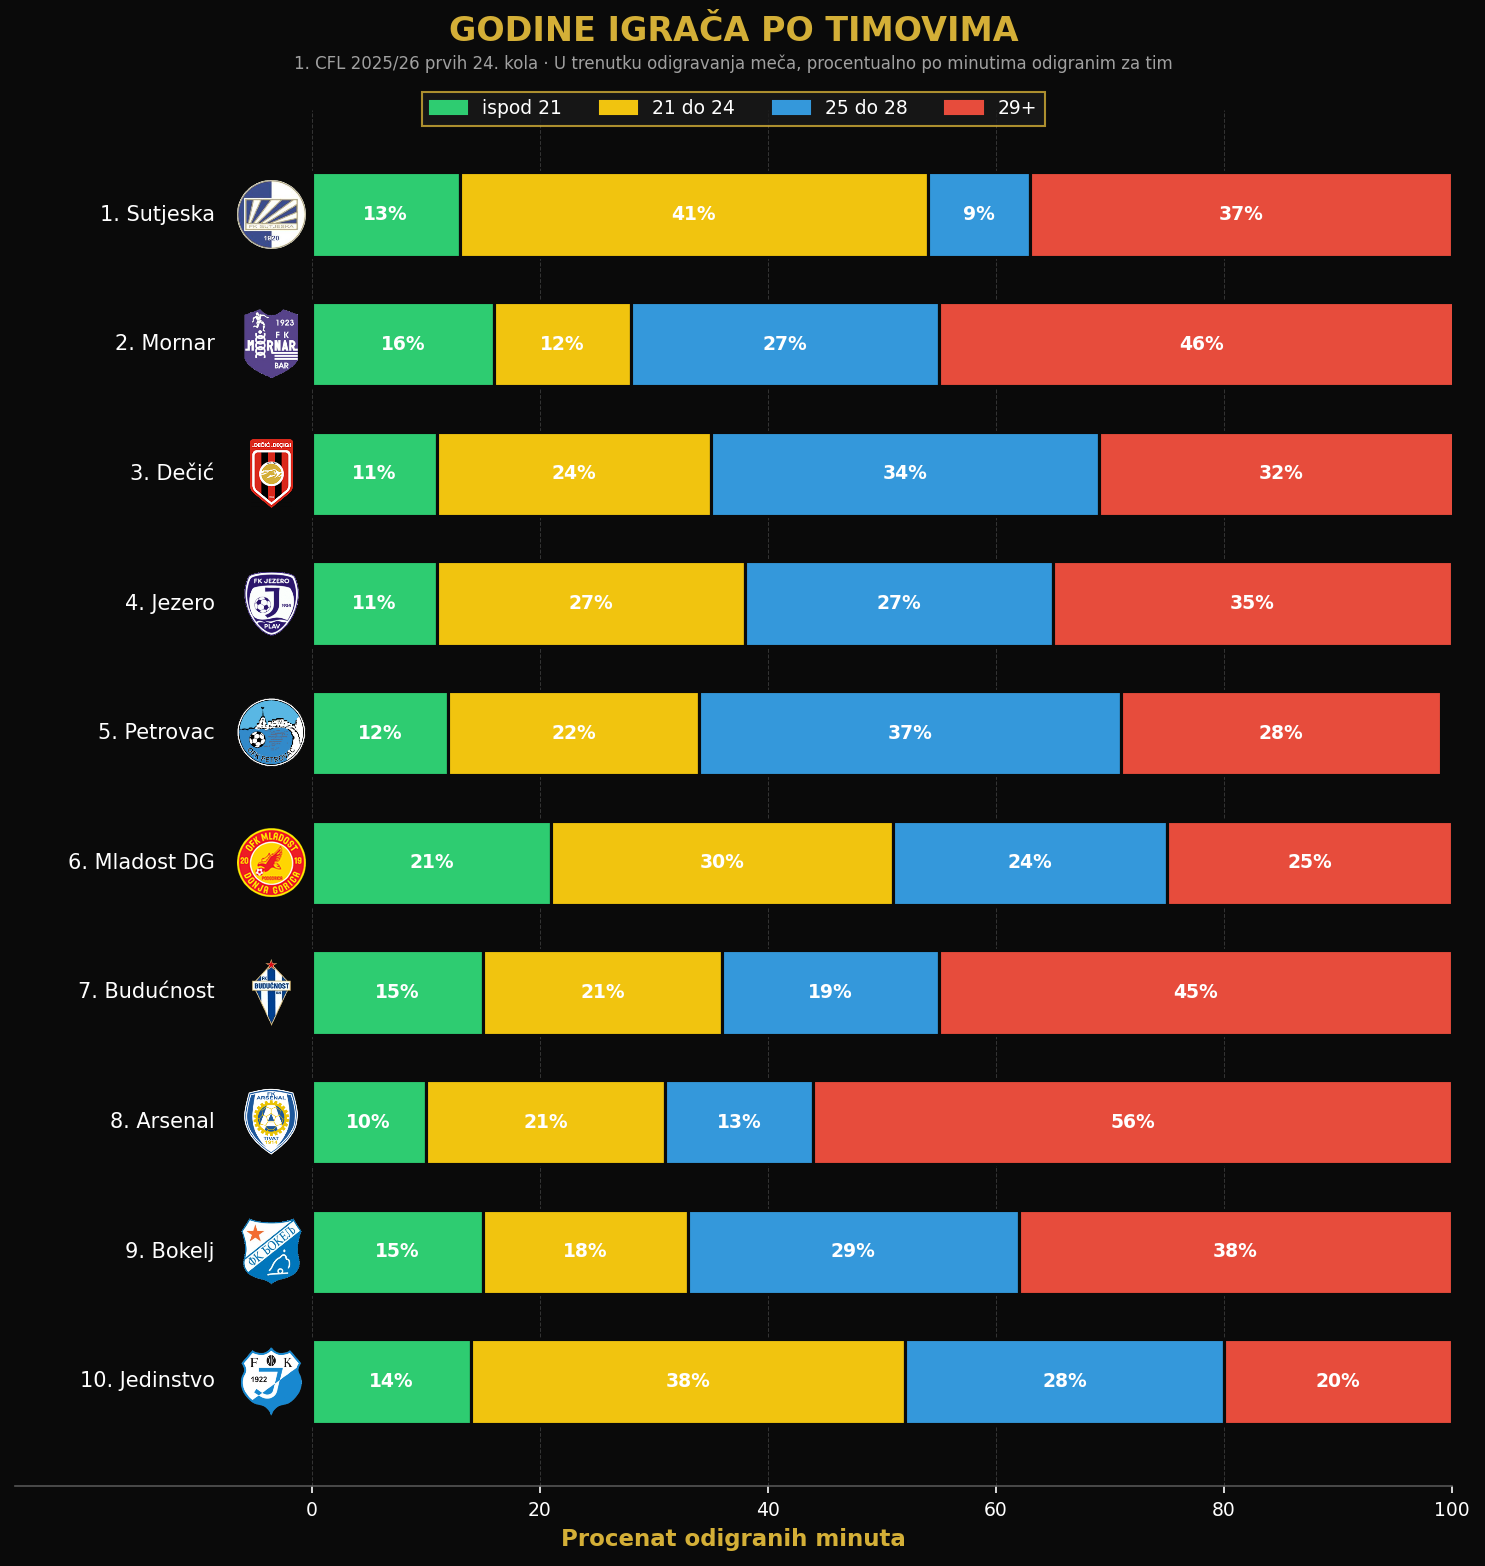

In [50]:

import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

BG_COLOR   = '#0a0a0a'
TEXT_COLOR = '#FFFFFF'
GOLD_COLOR = '#d4af37'

AGE_COLORS = {
    'Under 21': '#2ecc71',   # green
    '21 to 24': '#f1c40f',   # yellow
    '25 to 28': '#3498db',   # blue
    '29+':      '#e74c3c',   # red
}
LABELS_SR = {
    'Under 21': 'ispod 21',
    '21 to 24': '21 do 24',
    '25 to 28': '25 do 28',
    '29+':      '29+',
}

team_id_map = dict(zip(teams_meta['team_name'], teams_meta['team_id']))
TEAM_LOGOS_DIR = PROCESSED_DATA_DIR / 'team_logos'

n_teams = len(age_pivot_display)
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# ─── Stacked horizontal bars ────────────────────────────────────
lefts = [0] * n_teams
for cat in ['Under 21', '21 to 24', '25 to 28', '29+']:
    values = age_pivot_display[cat].values
    bars = ax.barh(
        range(n_teams), values, left=lefts,
        color=AGE_COLORS[cat], label=LABELS_SR[cat],
        edgecolor=BG_COLOR, linewidth=1.5, height=0.65,
    )
    for i, (val, left) in enumerate(zip(values, lefts)):
        if val >= 5:
            ax.text(
                left + val / 2, i, f"{int(val)}%",
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='white',
            )
    lefts = [l + v for l, v in zip(lefts, values)]

# ─── Order: text (pos# + name) | logo | bar ─────────────────────
ax.set_yticks([])
for y_idx, (orig_team, disp_name) in enumerate(zip(age_pivot.index, age_pivot_display.index)):
    ax.text(-8.5, y_idx, disp_name, ha='right', va='center',
            fontsize=10, color=TEXT_COLOR)
    team_id = team_id_map.get(orig_team)
    if team_id:
        logo_path = TEAM_LOGOS_DIR / f"{int(team_id)}.png"
        if logo_path.exists():
            try:
                logo_img = mpimg.imread(str(logo_path))
                im = OffsetImage(logo_img, zoom=0.22)
                ab = AnnotationBbox(im, (-3.5, y_idx),
                                    xycoords='data', frameon=False, pad=0, zorder=10)
                ax.add_artist(ab)
            except Exception as exc:
                print(f"Logo load failed for {team_id}: {exc}")

# ─── X axis — only show ticks 0–100, xlim extended left for labels ──
ax.set_xlim(-26, 100)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel('Procenat odigranih minuta', color=GOLD_COLOR, fontsize=11, fontweight='bold')
ax.tick_params(axis='x', colors=TEXT_COLOR, labelsize=9)
ax.tick_params(axis='y', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#555555')
ax.grid(axis='x', color='#333333', linewidth=0.5, linestyle='--')
ax.set_axisbelow(True)

# ─── Legend ─────────────────────────────────────────────────────
handles = [mpatches.Patch(color=AGE_COLORS[c], label=LABELS_SR[c])
           for c in ['Under 21', '21 to 24', '25 to 28', '29+']]
ax.legend(
    handles=handles, loc='upper center',
    ncol=4, frameon=True, fancybox=False,
    facecolor='#1a1a1a', edgecolor=GOLD_COLOR, labelcolor=TEXT_COLOR,
    fontsize=9, bbox_to_anchor=(0.5, 1.02),
)

# ─── Title ──────────────────────────────────────────────────────
fig.text(0.5, 1.05, 'GODINE IGRAČA PO TIMOVIMA', ha='center',
         fontsize=16, fontweight='bold', color=GOLD_COLOR, transform=ax.transAxes)
fig.text(0.5, 1.03, '1. CFL 2025/26 prvih 24. kola · U trenutku odigravanja meča, procentualno po minutima odigranim za tim',
         ha='center', fontsize=8, color='#A0A0A0', transform=ax.transAxes)

plt.tight_layout()
output_path = OUTPUT_DIR / 'team_age_distribution.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
print(f"✅ Saved to: {output_path}")
plt.show()


In [ ]:
# ─── Instagram Post Composition ─────────────────────────────
from PIL import Image

ASSETS_DIR = Path('..') / 'assets'
FINAL_DIR = Path('..') / 'outputs' / LEAGUE / 'final_posts'
FINAL_DIR.mkdir(parents=True, exist_ok=True)
INSTAGRAM_SIZE = (1080, 1350)
SAFE_ZONE = {'left': 30, 'top': 250, 'right': 1050, 'bottom': 1270}

for fig_name in ["team_age_distribution.png"]:
    chart_path = OUTPUT_DIR / fig_name
    if not chart_path.exists():
        print(f"Skipping {fig_name} (not found)")
        continue

    background = Image.open(ASSETS_DIR / 'background.png').convert('RGBA')
    if background.size != INSTAGRAM_SIZE:
        background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)

    chart = Image.open(chart_path).convert('RGBA')
    safe_w = SAFE_ZONE['right'] - SAFE_ZONE['left']
    safe_h = SAFE_ZONE['bottom'] - SAFE_ZONE['top']
    chart = chart.resize((safe_w, safe_h), Image.Resampling.LANCZOS)
    background.paste(chart, (SAFE_ZONE['left'], SAFE_ZONE['top']), chart)

    out_path = FINAL_DIR / fig_name
    background.convert('RGB').save(out_path, quality=95)
    print(f"Saved: {out_path}")

